In [1]:
import pandas as pd

import numpy as np

import time,datetime

import matplotlib

import matplotlib.pyplot as plt

import seaborn as sns

import calendar

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings 

warnings.filterwarnings('ignore') 

In [2]:
uber_data = pd.read_csv('data.csv')

In [3]:
uber_data

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Errand/Supplies
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
9235,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
9236,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
9237,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
9238,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site


In [4]:
#Now lets rename the columns and remove '*' from columns' name.
uber_data = uber_data.rename(columns = {uber_data.columns[0]:'START_DATE',
                                        uber_data.columns[1]:'END_DATE',
                                        uber_data.columns[2]:'CATEGORY',
                                        uber_data.columns[3]:'START',
                                        uber_data.columns[4]:'STOP',
                                        uber_data.columns[5]: 'MILES',
                                        uber_data.columns[6]:'PURPOSE'})

In [5]:
uber_data

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Errand/Supplies
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
9235,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
9236,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
9237,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
9238,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site


In [6]:
print(uber_data.isnull().sum())
print(uber_data.isnull().sum().sum())
uber_data=uber_data.dropna()

START_DATE      0
END_DATE        0
CATEGORY        0
START           0
STOP            0
MILES           0
PURPOSE       568
dtype: int64
568


In [7]:
uber_data[uber_data.START.str.contains('\?') == True]

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
140,2/20/2016 14:50,2/20/2016 15:54,Business,R?walpindi,R?walpindi,23.1,Meeting
656,8/15/2016 9:05,8/15/2016 9:52,Business,R?walpindi,Unknown Location,15.6,Temporary Site
670,8/17/2016 15:32,8/17/2016 15:47,Business,R?walpindi,Islamabad,6.4,Airport/Travel
679,8/19/2016 10:57,8/19/2016 11:06,Business,R?walpindi,Unknown Location,2.0,Airport/Travel
696,8/22/2016 20:53,8/22/2016 21:31,Business,R?walpindi,R?walpindi,4.1,Temporary Site
...,...,...,...,...,...,...,...
9232,12/30/2016 15:41,12/30/2016 16:03,Business,Kar?chi,Kar?chi,4.6,Errand/Supplies
9233,12/30/2016 16:45,12/30/2016 17:08,Business,Kar?chi,Kar?chi,4.6,Meeting
9234,12/30/2016 23:06,12/30/2016 23:10,Business,Kar?chi,Kar?chi,0.8,Customer Visit
9235,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting


In [8]:
uber_data['START'] = uber_data['START'].replace({"\?":"a"}, regex = True)
uber_data["STOP"] = uber_data["STOP"].replace({"\?":"a"}, regex = True)

In [9]:
import pandas as pd

# Custom parsing function
def parse_dates(date_str):
    try:
        return pd.to_datetime(date_str)
    except ValueError:
        # Handle or log the error
        return pd.NaT  # Or a default date, depending on your requirement

# Apply the custom function
uber_data['START_DATE'] = uber_data['START_DATE'].apply(parse_dates)
uber_data['END_DATE'] = uber_data['END_DATE'].apply(parse_dates)


In [10]:
uber_data['Start_Date'] = uber_data['START_DATE'].dt.date
uber_data['Start_Time'] = uber_data['START_DATE'].dt.time
uber_data['End_Date'] = uber_data['END_DATE'].dt.date
uber_data['End_Time'] = uber_data['END_DATE'].dt.time

In [11]:
uber_data['Distance'] = uber_data['MILES'] * 1.60934

In [12]:
uber_data

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,Start_Date,Start_Time,End_Date,End_Time,Distance
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21:11:00,2016-01-01,21:17:00,8.207634
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Errand/Supplies,2016-01-02,01:25:00,2016-01-02,01:37:00,8.046700
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20:25:00,2016-01-02,20:38:00,7.724832
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17:31:00,2016-01-05,17:45:00,7.563898
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14:42:00,2016-01-06,15:49:00,102.514958
...,...,...,...,...,...,...,...,...,...,...,...,...
9235,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Karachi,Karachi,0.7,Meeting,2016-12-31,01:07:00,2016-12-31,01:14:00,1.126538
9236,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Karachi,Unknown Location,3.9,Temporary Site,2016-12-31,13:24:00,2016-12-31,13:42:00,6.276426
9237,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting,2016-12-31,15:03:00,2016-12-31,15:38:00,26.071308
9238,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site,2016-12-31,21:32:00,2016-12-31,21:50:00,10.299776


In [13]:
def condition(uber_data):
    if uber_data['Distance'] <=10 :
        return 'Rs.50'
    elif uber_data['Distance'] <=20 :
        return 'Rs.70'
    elif uber_data['Distance'] <=100 :
        return 'Rs.80'
    else:
        return 'Rs.100'

uber_data['Tips'] = uber_data.apply(condition, axis=1)

In [14]:
uber_data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,Start_Date,Start_Time,End_Date,End_Time,Distance,Tips
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21:11:00,2016-01-01,21:17:00,8.207634,Rs.50
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Errand/Supplies,2016-01-02,01:25:00,2016-01-02,01:37:00,8.046700,Rs.50
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20:25:00,2016-01-02,20:38:00,7.724832,Rs.50
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17:31:00,2016-01-05,17:45:00,7.563898,Rs.50
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14:42:00,2016-01-06,15:49:00,102.514958,Rs.100


In [15]:
uber_data=uber_data[['Start_Date','Start_Time','End_Date','End_Time','CATEGORY','START','STOP','Distance','PURPOSE','Tips']]

In [16]:
uber_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8672 entries, 0 to 9239
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Start_Date  8672 non-null   object 
 1   Start_Time  8672 non-null   object 
 2   End_Date    8672 non-null   object 
 3   End_Time    8672 non-null   object 
 4   CATEGORY    8672 non-null   object 
 5   START       8672 non-null   object 
 6   STOP        8672 non-null   object 
 7   Distance    8672 non-null   float64
 8   PURPOSE     8672 non-null   object 
 9   Tips        8672 non-null   object 
dtypes: float64(1), object(9)
memory usage: 745.2+ KB


In [17]:
uber_data.columns

Index(['Start_Date', 'Start_Time', 'End_Date', 'End_Time', 'CATEGORY', 'START',
       'STOP', 'Distance', 'PURPOSE', 'Tips'],
      dtype='object')

In [18]:
uber_data['Tips'].value_counts()

Tips
Rs.50     4496
Rs.70     2416
Rs.80     1560
Rs.100     200
Name: count, dtype: int64

In [19]:
uber_data['PURPOSE'].value_counts()

PURPOSE
Meeting            2552
Meal/Entertain     2136
Customer Visit     1336
Errand/Supplies    1240
Temporary Site      936
Airport/Travel      304
Between Offices     120
Moving               32
Charity ($)           8
Commute               8
Name: count, dtype: int64

In [20]:
uber_data['CATEGORY'].value_counts()

CATEGORY
Business    8184
Personal     488
Name: count, dtype: int64

In [21]:
uber_data['CATEGORY'].value_counts()

CATEGORY
Business    8184
Personal     488
Name: count, dtype: int64

<Axes: xlabel='CATEGORY', ylabel='count'>

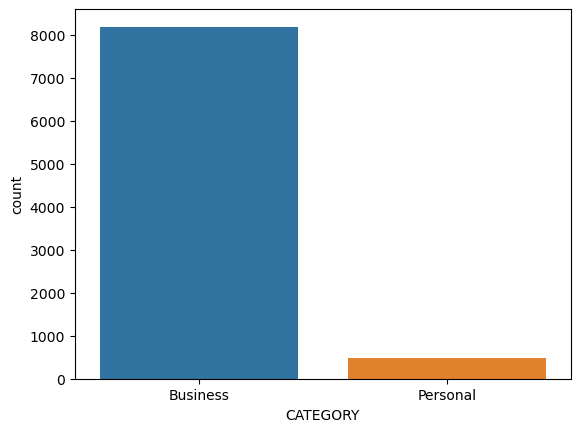

In [22]:
sns.countplot(x= 'CATEGORY' ,data=uber_data)

<Axes: xlabel='count', ylabel='PURPOSE'>

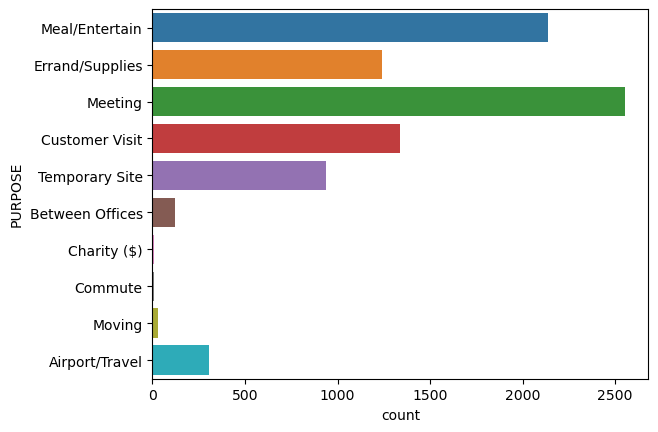

In [23]:
sns . countplot(y= 'PURPOSE' ,data=uber_data)

Text(0.5, 1.0, 'Number of Trips by Pickup points')

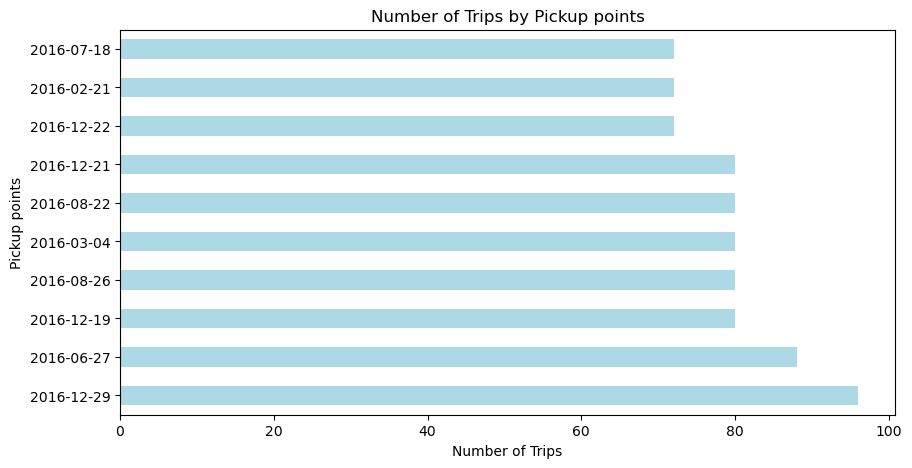

In [24]:
pic_point = uber_data[ 'Start_Date' ].value_counts().nlargest(10)
pic_point.plot(kind='barh', color= 'lightblue', figsize=(10, 5))
plt.xlabel('Number of Trips')
plt.ylabel('Pickup points' )
plt.title( 'Number of Trips by Pickup points')

In [25]:
uber_data

,Start_Date,Start_Time,End_Date,End_Time,CATEGORY,START,STOP,Distance,PURPOSE,Tips
0,2016-01-01,21:11:00,2016-01-01,21:17:00,Business,Fort Pierce,Fort Pierce,8.207634,Meal/Entertain,Rs.50
1,2016-01-02,01:25:00,2016-01-02,01:37:00,Business,Fort Pierce,Fort Pierce,8.046700,Errand/Supplies,Rs.50
2,2016-01-02,20:25:00,2016-01-02,20:38:00,Business,Fort Pierce,Fort Pierce,7.724832,Errand/Supplies,Rs.50
3,2016-01-05,17:31:00,2016-01-05,17:45:00,Business,Fort Pierce,Fort Pierce,7.563898,Meeting,Rs.50
4,2016-01-06,14:42:00,2016-01-06,15:49:00,Business,Fort Pierce,West Palm Beach,102.514958,Customer Visit,Rs.100
...,...,...,...,...,...,...,...,...,...,...
9235,2016-12-31,01:07:00,2016-12-31,01:14:00,Business,Karachi,Karachi,1.126538,Meeting,Rs.50
9236,2016-12-31,13:24:00,2016-12-31,13:42:00,Business,Karachi,Unknown Location,6.276426,Temporary Site,Rs.50
9237,2016-12-31,15:03:00,2016-12-31,15:38:00,Business,Unknown Location,Unknown Location,26.071308,Meeting,Rs.80
9238,2016-12-31,21:32:00,2016-12-31,21:50:00,Business,Katunayake,Gampaha,10.299776,Temporary Site,Rs.70


In [26]:
X=uber_data.drop(['Tips'],axis=1)
y=uber_data["Tips"]

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(6937, 9) (1735, 9) (6937,) (1735,)


In [28]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
numeric_features = ['Distance']
categorical_features = ['Start_Date','Start_Time','End_Date','End_Time','CATEGORY','START','STOP','PURPOSE']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Replace missing values with median
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')),  # One-hot encode categorical variables
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ])

In [29]:
from sklearn.ensemble import RandomForestClassifier
RF = Pipeline(steps=[('preprocessor', preprocessor),
                     ('classifier', RandomForestClassifier(n_estimators=100, max_depth=5))])
RF.fit(X_train, y_train)
y_pred = RF.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='micro')  
recall = recall_score(y_test, y_pred, average='micro')       
f1 = f1_score(y_test, y_pred, average='micro')                

print(f'Model Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')

Model Accuracy: 0.5221902017291066
Precision: 0.5221902017291066
Recall: 0.5221902017291066
F1 Score: 0.5221902017291066


In [30]:
from sklearn.svm import SVC
sv = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', SVC())])

sv.fit(X_train, y_train)

# Make predictions on the test set
y_pred = sv.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='micro')  
recall = recall_score(y_test, y_pred, average='micro')       
f1 = f1_score(y_test, y_pred, average='micro')  

print(f'Model Accuracy: {accuracy}')
print(f'Precision : {precision}')
print(f'Recall : {recall}')
print(f'F1 Score: {f1}')

Model Accuracy: 0.9815561959654179
Precision : 0.9815561959654179
Recall : 0.9815561959654179
F1 Score: 0.9815561959654179


In [31]:
from sklearn.linear_model import Perceptron
pt = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', Perceptron())])

pt.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='micro')  
recall = recall_score(y_test, y_pred, average='micro')       
f1 = f1_score(y_test, y_pred, average='micro')  

print(f'Model Accuracy: {accuracy}')
print(f'Precision : {precision}')
print(f'Recall : {recall}')
print(f'F1 Score: {f1}')

Model Accuracy: 0.9510086455331412
Precision : 0.9510086455331412
Recall : 0.9510086455331412
F1 Score: 0.9510086455331412


In [32]:
uber_data

,Start_Date,Start_Time,End_Date,End_Time,CATEGORY,START,STOP,Distance,PURPOSE,Tips
0,2016-01-01,21:11:00,2016-01-01,21:17:00,Business,Fort Pierce,Fort Pierce,8.207634,Meal/Entertain,Rs.50
1,2016-01-02,01:25:00,2016-01-02,01:37:00,Business,Fort Pierce,Fort Pierce,8.046700,Errand/Supplies,Rs.50
2,2016-01-02,20:25:00,2016-01-02,20:38:00,Business,Fort Pierce,Fort Pierce,7.724832,Errand/Supplies,Rs.50
3,2016-01-05,17:31:00,2016-01-05,17:45:00,Business,Fort Pierce,Fort Pierce,7.563898,Meeting,Rs.50
4,2016-01-06,14:42:00,2016-01-06,15:49:00,Business,Fort Pierce,West Palm Beach,102.514958,Customer Visit,Rs.100
...,...,...,...,...,...,...,...,...,...,...
9235,2016-12-31,01:07:00,2016-12-31,01:14:00,Business,Karachi,Karachi,1.126538,Meeting,Rs.50
9236,2016-12-31,13:24:00,2016-12-31,13:42:00,Business,Karachi,Unknown Location,6.276426,Temporary Site,Rs.50
9237,2016-12-31,15:03:00,2016-12-31,15:38:00,Business,Unknown Location,Unknown Location,26.071308,Meeting,Rs.80
9238,2016-12-31,21:32:00,2016-12-31,21:50:00,Business,Katunayake,Gampaha,10.299776,Temporary Site,Rs.70


In [33]:
new_data = {'Start_Date': '2016-01-06',
            'Start_Time': '14:42:00',
            'End_Date': '2016-01-06',
            'End_Time': '15:49:00',
            'CATEGORY': 'Business',
            'START': 'Fort Pierce',
            'STOP': 'West Palm Beach',
            'Distance': 102.514958,
            'PURPOSE': 'Customer Visit' 
           }

# Create a DataFrame from the input data
new_df = pd.DataFrame([new_data])

# Use the trained model to make predictions
prediction = sv.predict(new_df)
prediction[0]

'Rs.100'

In [34]:
new_data = {'Start_Date': '2016-01-01',
            'Start_Time': '21:11:00',
            'End_Date': '2016-01-01',
            'End_Time': '21:17:00',
            'CATEGORY': 'Business',
            'START': 'Fort Pierce',
            'STOP': 'Fort Pierce',
            'Distance': 8.207634,
            'PURPOSE': 'Meal/Entertain' 
           }

# Create a DataFrame from the input data
new_df = pd.DataFrame([new_data])

# Use the trained model to make predictions
prediction = sv.predict(new_df)
prediction[0]

'Rs.50'

In [35]:
import pickle
# Dump the trained svm classifier with Pickle
svm_filename = 'model.pkl'
# Open the file to save as pkl file
svm_Model_pkl = open(svm_filename, 'wb')
pickle.dump(sv,svm_Model_pkl)
# Close the pickle instances
svm_Model_pkl.close()